<a href="https://colab.research.google.com/github/rithika-66/X_RAY_BASED_BONE_FRACTURE_DETECTION/blob/main/Elbow_MobileNetV2(acc_78_28).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 4016 files belonging to 2 classes.
Found 465 files belonging to 2 classes.
Classes: ['negative', 'positive']

🚀 Phase 1: Training Frozen Base
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5244 - loss: 1.1645
Epoch 1: val_accuracy improved from -inf to 0.64516, saving model to /content/drive/MyDrive/XR_ELBOW/models/best_mobilenetv2.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.5246 - loss: 1.1636 - val_accuracy: 0.6452 - val_loss: 0.6040 - learning_rate: 1.0000e-04
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6068 - loss: 0.8563
Epoch 2: val_accuracy improved from 0.64516 to 0.65376, saving model to /content/drive/MyDrive/XR_ELBOW/models/best_mobilenetv2.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.6067 - loss: 0.8565 - val_accuracy: 0.6538 - val_loss: 0.5920 - learning_rate: 1.

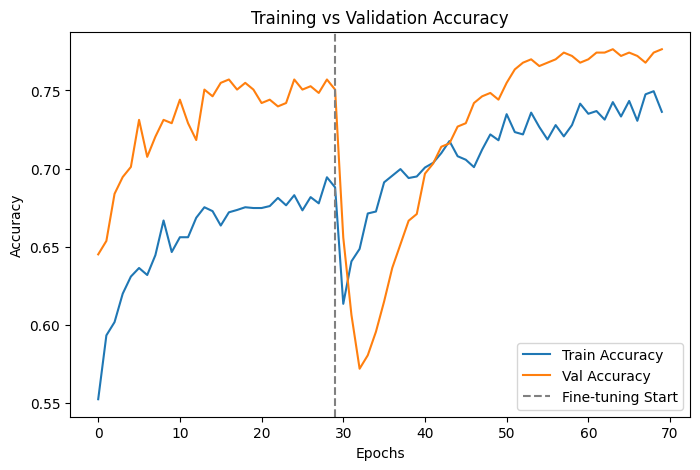

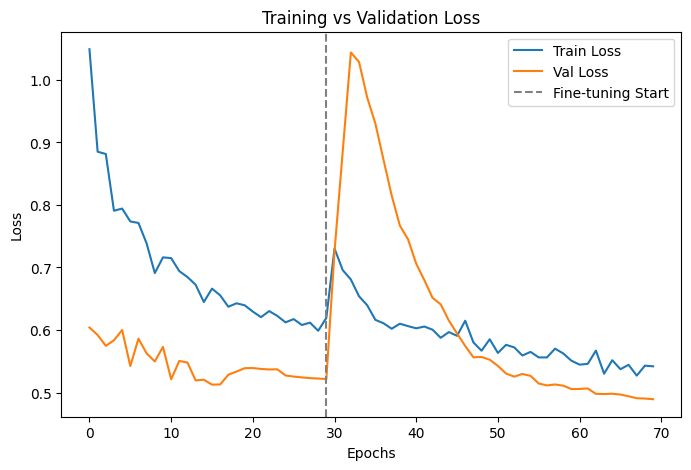

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


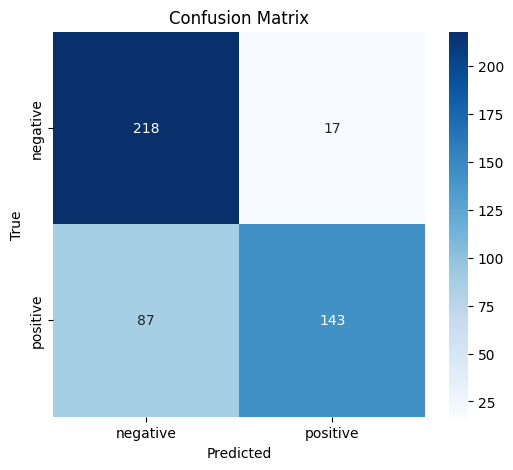


Classification Report:

              precision    recall  f1-score   support

    negative       0.71      0.93      0.81       235
    positive       0.89      0.62      0.73       230

    accuracy                           0.78       465
   macro avg       0.80      0.77      0.77       465
weighted avg       0.80      0.78      0.77       465



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import time
import os
from google.colab import drive

# ===============================
# MOUNT GOOGLE DRIVE
# ===============================
drive.mount('/content/drive')

# ===============================
# PATHS
# ===============================
train_dir = "/content/drive/MyDrive/XR_ELBOW/Train"
test_dir  = "/content/drive/MyDrive/XR_ELBOW/Valid"

MODEL_DIR = "/content/drive/MyDrive/XR_ELBOW/models"
MODEL_PATH = f"{MODEL_DIR}/best_mobilenetv2.keras"

os.makedirs(MODEL_DIR, exist_ok=True)

# ===============================
# HYPERPARAMETERS
# ===============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 30
EPOCHS_PHASE2 = 40
LR_PHASE1 = 1e-4
LR_PHASE2 = 1e-5

# ===============================
# LOAD DATA
# ===============================
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# ===============================
# DATA AUGMENTATION
# ===============================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.25),
    tf.keras.layers.RandomZoom(0.25),
    tf.keras.layers.RandomContrast(0.25),
])

# ===============================
# MODEL
# ===============================
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

# ===============================
# COMPILE PHASE 1
# ===============================
model.compile(
    optimizer=Adam(learning_rate=LR_PHASE1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

lr_reduction = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
    verbose=1
)

# ===============================
# PHASE 1 TRAINING
# ===============================
print("\n🚀 Phase 1: Training Frozen Base")
start = time.time()

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=[checkpoint, lr_reduction]
)

print(f"Phase 1 completed in {(time.time()-start)/60:.2f} minutes")

# ===============================
# PHASE 2 FINE-TUNING
# ===============================
print("\n🔧 Phase 2: Fine-tuning")

base_model.trainable = True
for layer in base_model.layers[:80]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LR_PHASE2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=[checkpoint, lr_reduction]
)

# ===============================
# LOAD BEST MODEL
# ===============================
model = tf.keras.models.load_model(MODEL_PATH)

loss, acc = model.evaluate(test_ds)
print(f"\n✅ Final Test Accuracy: {acc*100:.2f}%")

# ===============================
# COMBINE HISTORY
# ===============================
acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss = history.history['loss'] + history_ft.history['loss']
val_loss = history.history['val_loss'] + history_ft.history['val_loss']

# ===============================
# ACCURACY PLOT
# ===============================
plt.figure(figsize=(8,5))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=len(history.history['accuracy'])-1, linestyle='--', color='gray', label='Fine-tuning Start')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# ===============================
# LOSS PLOT
# ===============================
plt.figure(figsize=(8,5))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=len(history.history['loss'])-1, linestyle='--', color='gray', label='Fine-tuning Start')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# ===============================
# CONFUSION MATRIX
# ===============================
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
/content/drive/MyDrive/XR_ELBOW/models/best_mobilenetv2.keras


In [ ]:
!pip install gradio shap opencv-python tensorflow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: File not found: filepath=/content/drive/MyDrive/XR_ELBOW/models/best_mobilenetv2.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import time
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Paths
train_dir = "/content/drive/MyDrive/XR_ELBOW/Train"
test_dir = "/content/drive/MyDrive/XR_ELBOW/Valid"

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4

Mounted at /content/drive


Found 4016 files belonging to 2 classes.
Found 465 files belonging to 2 classes.
Classes: ['negative', 'positive']
Starting Phase 1 training...
Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.5374 - loss: 1.0347 - val_accuracy: 0.6387 - val_loss: 0.6256 - learning_rate: 1.0000e-04
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.5854 - loss: 0.8874 - val_accuracy: 0.6968 - val_loss: 0.5833 - learning_rate: 1.0000e-04
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.6068 - loss: 0.8209 - val_accuracy: 0.6925 - val_loss: 0.5810 - learning_rate: 1.0000e-04
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.6148 - loss: 0.7965 - val_accuracy: 0.6946 - val_loss: 0.5898 - learning_rate: 1.0000e-04
Epoch 5/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.6304 - loss: 0.7739 - val_accuracy: 0.7032 - val_loss: 0.5692 - learning_rate: 1.0000e-04
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.628

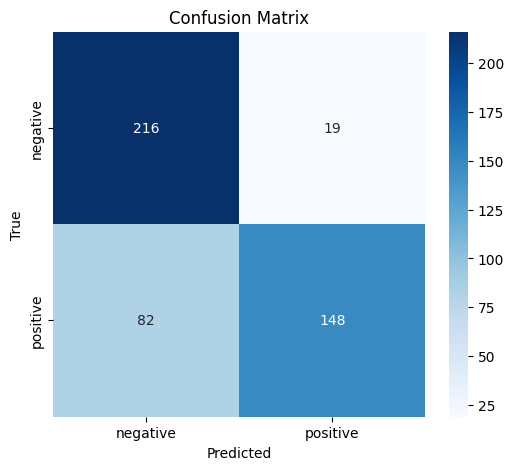


Classification Report:

              precision    recall  f1-score   support

    negative       0.72      0.92      0.81       235
    positive       0.89      0.64      0.75       230

    accuracy                           0.78       465
   macro avg       0.81      0.78      0.78       465
weighted avg       0.80      0.78      0.78       465



In [ ]:

# --- Load datasets ---
train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)
test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# --- Data Augmentation ---
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomBrightness(factor=0.3)
])

# --- Base Model ---
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# --- Build Model ---
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation='softmax')(x)
model = Model(inputs, outputs)

# --- Compile ---
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Callbacks (No EarlyStopping) ---
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)
checkpoint = ModelCheckpoint("best_model_mobilenetv2.keras", save_best_only=True,
                             monitor='val_accuracy', mode='max')

# --- Phase 1: Frozen Base Training ---
print("Starting Phase 1 training...")
start = time.time()
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,  # Increase epochs
    callbacks=[lr_reduction, checkpoint]
)
print(f"Phase 1 completed in {(time.time()-start)/60:.2f} minutes")

# --- Phase 2: Fine-tuning ---
print("Starting Phase 2 fine-tuning...")
base_model.trainable = True
for layer in base_model.layers[:80]:
    layer.trainable = False  # Keep early layers frozen

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 40
history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=fine_tune_epochs,
    callbacks=[lr_reduction, checkpoint]
)

# --- Evaluate ---
model.load_weights("best_model_mobilenetv2.keras")
loss, acc = model.evaluate(test_ds)
print(f"✅ Final Test Accuracy: {acc*100:.2f}%")

# --- Confusion Matrix ---
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


NameError: name 'tf' is not defined